# Actividad 3
## Preparación de los datos

In [23]:
import pandas as pd

try:
    df = pd.read_csv('../Datasets/season-2425.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo.")

display(df)

print(f"Valores nulos por columna:\n{df.isnull().sum()}") 


Dataset cargado exitosamente.


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,15/08/24,Ath Bilbao,Getafe,1,1,D,1,0,H,NaN,...,4,2,15,12,5,6,4,1,0,0
1,15/08/24,Betis,Girona,1,1,D,1,0,H,NaN,...,4,2,11,7,4,4,2,0,0,0
2,16/08/24,Celta,Alaves,2,1,H,0,1,A,NaN,...,4,2,8,23,3,3,3,2,0,0
3,16/08/24,Las Palmas,Sevilla,2,2,D,1,1,D,NaN,...,5,5,12,13,6,3,0,0,0,0
4,17/08/24,Osasuna,Leganes,1,1,D,0,1,A,NaN,...,5,4,14,12,6,4,3,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,24/05/25,Getafe,Celta,1,2,A,1,1,D,NaN,...,1,8,13,10,2,6,3,4,1,0
376,24/05/25,Vallecano,Mallorca,0,0,D,0,0,D,NaN,...,8,2,9,14,11,2,2,2,0,0
377,25/05/25,Girona,Ath Madrid,0,4,A,0,0,D,NaN,...,1,11,13,11,1,8,0,1,0,0
378,25/05/25,Villarreal,Sevilla,4,2,H,3,1,H,NaN,...,7,6,8,14,3,5,0,1,0,0


Valores nulos por columna:
Date          0
HomeTeam      0
AwayTeam      0
FTHG          0
FTAG          0
FTR           0
HTHG          0
HTAG          0
HTR           0
Referee     380
HS            0
AS            0
HST           0
AST           0
HF            0
AF            0
HC            0
AC            0
HY            0
AY            0
HR            0
AR            0
dtype: int64


## Modelado y evaluación

Matriz de correlación (Pearson):


,FTHG,FTAG,HTHG,HTAG,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
FTHG,1.000000,-0.022713,0.714738,0.010147,NaN,0.290849,-0.152988,0.549903,-0.037894,-0.140492,-0.028067,0.039377,-0.087280,-0.106802,-0.043084,-0.126777,0.048597
FTAG,-0.022713,1.000000,0.024303,0.631684,NaN,-0.086224,0.287035,-0.040544,0.617196,-0.001186,-0.044481,-0.028891,0.037167,0.126627,-0.009744,0.123309,-0.026502
HTHG,0.714738,0.024303,1.000000,-0.010712,NaN,0.124240,-0.035952,0.331700,0.034929,-0.103163,0.006988,-0.044631,0.023317,-0.153531,-0.000183,-0.056266,0.006410
HTAG,0.010147,0.631684,-0.010712,1.000000,NaN,0.053682,0.101573,0.054715,0.372129,0.026854,-0.015281,0.116290,-0.101631,0.135645,0.005797,0.040805,0.041838
Referee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HS,0.290849,-0.086224,0.124240,0.053682,NaN,1.000000,-0.413966,0.716738,-0.270149,-0.194559,-0.138403,0.621327,-0.338048,-0.187757,0.011411,-0.205594,0.118840
AS,-0.152988,0.287035,-0.035952,0.101573,NaN,-0.413966,1.000000,-0.257792,0.647651,0.051577,-0.093386,-0.356969,0.541497,0.143986,-0.032536,0.251476,-0.041174
HST,0.549903,-0.040544,0.331700,0.054715,NaN,0.716738,-0.257792,1.000000,-0.141079,-0.182167,-0.077648,0.435648,-0.231192,-0.145210,0.017598,-0.176946,0.137298
AST,-0.037894,0.617196,0.034929,0.372129,NaN,-0.270149,0.647651,-0.141079,1.000000,0.060267,-0.139534,-0.207175,0.304572,0.056391,-0.089978,0.148402,-0.020889
HF,-0.140492,-0.001186,-0.103163,0.026854,NaN,-0.194559,0.051577,-0.182167,0.060267,1.000000,-0.000162,-0.131360,-0.055881,0.306308,0.117886,0.004346,0.066716


Matriz de correlación ilustrativa(Pearson):


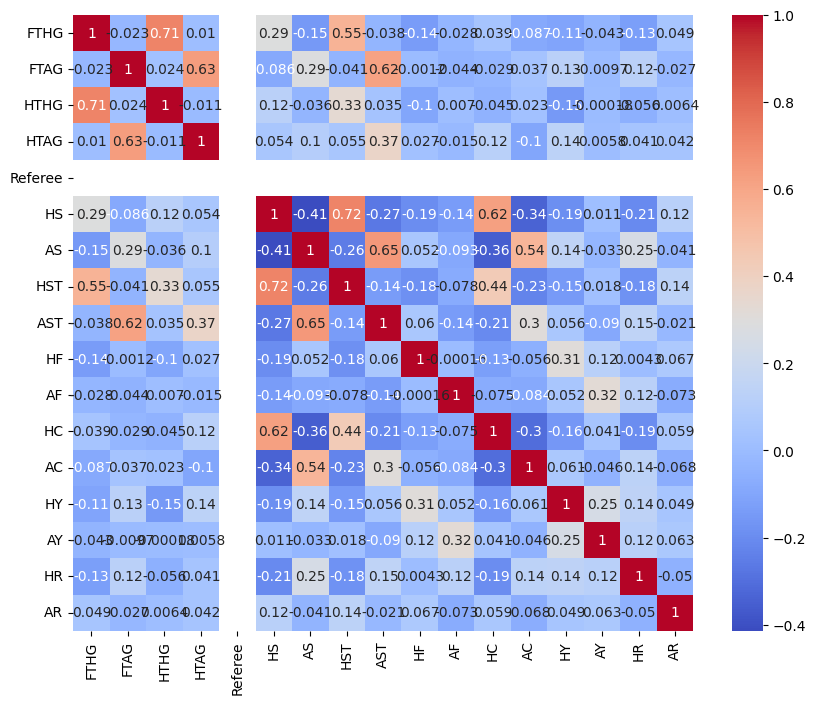

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

pearson = df.select_dtypes(include=['number']).corr(method='pearson')
print("Matriz de correlación (Pearson):")
display(pearson)

# matriz de correlación
print("Matriz de correlación ilustrativa(Pearson):")
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(method='pearson', numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X = df[["HC"]]
y = df["HS"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")
 
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print(f"Ecuación: R = {modelo.intercept_} + {modelo.coef_[0]} x HC")

Entrenamiento: 304 | Prueba: 76
Ecuación: R = 7.280033323566317 + 1.111232716718037 x HS


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
root_mean = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {root_mean:.4f}")
R2 = r2_score(y_test, y_pred)
print(f"R2   : {R2:.4f}")

RMSE : 3.8207
R2   : 0.4086


# Concluciones

- (HS = 7.28 + 1.11 × HC) La ecuacion significa que, por cada córner adicional del equipo local, se esperan aproximadamente 1.11 disparos más. El intercepto de 7.28 indica que incluso sin córners, un equipo local promedia ~7 disparos.
- El modelo solo explica el 41% de la varianza en los disparos del equipo local. Esto indica un ajuste moderado-bajo: HC tiene cierta relación con HS, pero más de la mitad de los disparos queda sin explicar por los córners solos.
- El error promedio de predicción es de casi 4 disparos por partido (RMSE = 3.82 disparos), lo cual es considerable si los equipos promedian entre 10–15 disparos.
- El modelo es un punto de partida válido, pero no suficiente para predicciones confiables.